### __Packages__

In [82]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
from typing import Union
import json
import glob
import yaml
from matplotlib.cm import GnBu
from matplotlib.colors import Normalize

### Figure Save Path

In [83]:
cwd = Path.cwd()
save_path = cwd / "data" / "SAM-1000L-B7H4-experiment"

### __Functions__

In [84]:
def json_to_dict(json_file_path: Union[str, Path]):
    """
    The function `json_to_dict` reads a JSON file and returns its contents as a
    dictionary.

    Args:
      json_file_path (Union[str, Path]): The `json_file_path` parameter is the
      file path to the JSON
    file that you want to read and convert into a Python dictionary. This
    function reads the JSON data from the specified file and returns it as a
    dictionary.

    Returns:
      The function `json_to_dict` returns a dictionary object containing the
      data loaded from the JSON
    file located at the specified file path.
    """
    with open(json_file_path, "r", encoding="utf-8") as file:
        json_dict = json.load(file)

    file.close()

    return json_dict

In [85]:
def read_config(path_directory: Union[str, Path]):
    """
    The `read_config` function reads a YAML file containing experiment configuration data and
    returns the parsed configuration.

    Returns:
      The function `read_config` returns the experiment configuration data loaded from the
      first YAML file found in the specified directory.
    """
    # yaml_files = glob.glob(str(Path(path_directory, "*.yaml")))
    yaml_data = open(path_directory, "r", encoding="utf-8")
    yaml_config = yaml.safe_load(yaml_data)
    yaml_data.close()

    return yaml_config

In [86]:
def per_interval_qp_simple(t, P, Xv):
    t = np.asarray(t)
    P = np.asarray(P)
    Xv = np.asarray(Xv)
    idx = np.argsort(t)
    t, P, Xv = t[idx], P[idx], Xv[idx]

    dt = np.diff(t)
    dP = np.diff(P)
    Xv_avg = 0.5 * (Xv[:-1] + Xv[1:])
    denom = Xv_avg * dt
    qp = np.where(denom != 0, dP / denom, np.nan)
    return qp, Xv_avg

### Import Batch Data and Yaml Config File

In [87]:
file_path = Path.cwd() / "data"
folder = "SAM-1000L-B7H4-experiment"
filename_data = "SAM-1000L-B7H4-MasterDataTable.json"
filename_yaml = "SAM-1000L-B7H4.yaml"
full_path_data = file_path / folder / filename_data
full_path_yaml = file_path / folder / filename_yaml

mpc_data = json_to_dict(full_path_data)
mpc_yaml = read_config(full_path_yaml)
mpc_yaml

{'Asset': 'B7H4',
 'Vessel ID': 'FER027',
 'Campaign ID': 'GSK5730912',
 'Lot ID': '57309120M00D00',
 'Batch ID': '5730912101002F',
 'Inoc Date': datetime.date(2025, 11, 21),
 'Last Day': 14,
 'Feed Type': 'B',
 'Tubing Factor': 7.2,
 'Maximum Pump Speed': 190,
 'Bolus Feed Flowrate': 1360,
 'Scale': '1000L',
 'Initial Volumes': {'ambr250': 0.19, '1000L': 740.0, '2000L': 1740.0},
 'Volume Unit': 'L',
 'Feed Unit': 'mL',
 'Master Data File': 'SAM-1000L-B7H4-MasterDataTable.json',
 'Units Dictionary': {'IGG': 'mg/L',
  'LDH': 'mg/L',
  'TCC': 'MM cells/mL',
  'VCC': 'MM cells/mL',
  'VIABILITY': '%',
  'DIAMETER': 'um',
  'OSMOLALITY': 'mOsm/kg',
  'AMMONIUM': 'mM',
  'CALCIUM': 'mg/L',
  'GLUCOSE': 'g/L',
  'GLUTAMINE': 'mM',
  'GLUTAMATE': 'mM',
  'LACTATE': 'g/L',
  'PH': '',
  'PCO2': 'mmHg',
  'PO2': 'mmHg',
  'POTASSIUM': 'mg/L',
  'SODIUM': 'mg/L',
  'BICARBONATE': None,
  'PCO2_AT_TEMP': 'mmHg',
  'PO2_AT_TEMP': 'mmHg',
  'PH_AT_TEMP': '',
  'PH_SETPOINT': '',
  'TEMPERATURE_SETP

### __Reference Data__

In [89]:
folder = r"C:\Users\zah48132\GSK\Biopharm Model Predictive Control - Documents\General\doc\SAM Lab 1000L Batch November 2025"
file = "CTM_data_for_titer_trajectory.csv"
file_path = Path(folder, file)

df = pd.read_csv(file_path)
df_ctm = df.loc[df["Location"]=="B38", :]
grouped = df_ctm.groupby("Day")["titer"].agg(['mean','std'])
df_agg = grouped.reset_index()
df_agg

,Day,mean,std
0,0,21.050000,4.030509
1,1,33.150000,2.616295
2,2,59.550000,10.253048
3,3,120.328571,13.004578
4,4,230.314286,22.308999
5,5,408.971429,35.335332
6,6,708.442857,53.809474
7,7,1046.471429,64.357302
8,8,1491.571429,62.262233
9,9,1845.685714,64.588503


In [90]:
file_path = Path.cwd() / "data"
folder_ctms = "SAM-1000L-B7H4-experiment"
filename_data_ctms = "ctm-historical-batches-data.csv"
full_path_data_ctms = file_path / folder_ctms / filename_data_ctms

all_ctm_data = pd.read_csv(full_path_data_ctms)
all_ctm_data["Time"] = pd.to_datetime(all_ctm_data["Time"])
all_ctm_data

,Batch,Time,Day,VCC,Viability,Titer,lactate,glucose,ammonium,glutamate,glutamine,osmolality,Total_Base_Added
0,CTM1,2025-03-05 10:50:00,0,0.61,100.0,23.9,0.06,6.38,0.49,2.80,0.70,309.0,0.0
1,CTM1,2025-03-06 09:31:00,1,1.05,99.0,35.0,0.18,6.27,0.70,3.04,0.72,310.0,0.0
2,CTM1,2025-03-07 14:20:00,2,2.33,99.0,66.8,0.40,5.72,1.15,3.28,0.64,301.0,0.0
3,CTM1,2025-03-08 08:11:00,3,3.77,99.0,105.1,0.54,5.23,1.70,3.57,0.62,301.0,0.0
4,CTM1,2025-03-09 08:16:00,4,6.93,100.0,198.5,0.79,3.92,2.35,3.95,0.54,287.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,CTM9,2025-09-05 09:11:00,10,17.28,93.4,2157.5,0.11,3.47,6.54,7.64,NaN,349.0,19.3
131,CTM9,2025-09-06 08:56:00,11,16.33,89.6,2375.7,0.11,3.59,7.86,7.90,NaN,374.0,19.3
132,CTM9,2025-09-07 08:53:00,12,15.98,85.6,2610.2,0.13,3.44,8.03,7.80,NaN,373.0,19.3
133,CTM9,2025-09-08 08:48:00,13,15.19,84.3,2760.0,0.16,3.63,8.93,8.35,NaN,402.0,19.3


### __Online Data__

In [91]:
file_path = Path.cwd() / "data"
folder_online = "SAM-1000L-B7H4-experiment"
filename_data_online = "online_data_temp.csv"
full_path_data_online = file_path / folder_online / filename_data_online

online_data = pd.read_csv(full_path_data_online)
online_data["Time"] = pd.to_datetime(online_data["Time"])
online_data

C:\Users\zah48132\AppData\Local\Temp\ipykernel_29704\4241419024.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  online_data["Time"] = pd.to_datetime(online_data["Time"])


,Time,FER027 TITER PV,FER027 TITER CSP,FER027 TITER COUT,FER027 PH PV,FER027 PH CSP,FER027 PH COUT,FER027 TEMP PRI PV,FER027 TEMP PRI CSP,FER027 TEMP PRI COUT
0,2025-11-21 12:00:00,-95.111206,21.824137,0,7.257392,7.104594,36.337517,36.612049,36.604134,37.339336
1,2025-11-21 12:15:00,-79.040161,21.947670,0,7.257050,7.104594,46.304447,36.615669,36.604134,37.322830
2,2025-11-21 12:30:00,-77.619263,22.071203,0,7.255237,7.104594,33.745888,36.612049,36.604134,37.330963
3,2025-11-21 12:45:00,-81.562866,22.194735,0,7.258060,7.104594,43.745308,36.601200,36.604134,37.364414
4,2025-11-21 13:00:00,-82.373657,22.318268,0,7.252885,7.104594,50.000000,36.597584,36.604134,37.380249
...,...,...,...,...,...,...,...,...,...,...
1324,2025-12-05 07:00:00,2912.947754,3267.348701,0,6.949709,7.038038,50.000000,36.376953,36.379360,36.944374
1325,2025-12-05 07:15:00,2927.724121,3269.273314,0,6.949666,7.038038,50.000000,36.378761,36.379360,36.939205
1326,2025-12-05 07:30:00,2901.462891,3271.197926,0,6.949790,7.038038,50.000000,36.373337,36.379360,36.955856
1327,2025-12-05 07:45:00,2947.833984,3273.122539,0,6.950326,7.038038,50.000000,36.396847,36.379360,36.874523


C:\Users\zah48132\AppData\Local\Temp\ipykernel_29704\660908081.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fontsize=10, loc="best")


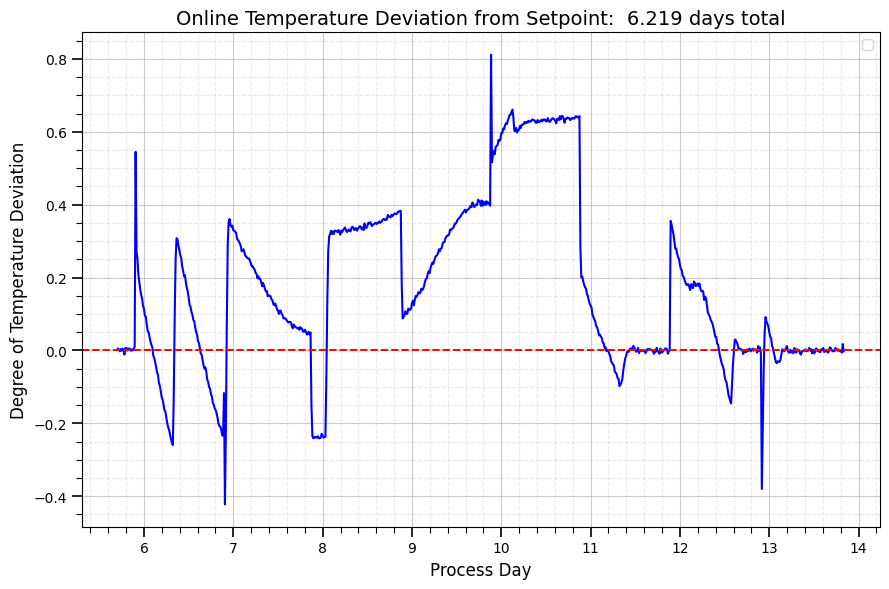

In [10]:
filter_day = 5.7
tolerance = 0.02

dt = online_data['Time'].diff().dt.total_seconds() / 86400  # same units as time
x = np.cumsum(dt)
online_data["Elapsed_time"] = x
online_data['deg_hr'] = ((online_data['FER027 TEMP PRI  PV'] - online_data['FER027 TEMP PRI  CSP']))

online_data_filtered = online_data[online_data["Elapsed_time"]>filter_day]
mask = np.where(abs(online_data_filtered['deg_hr'])>tolerance)[0]
degree_deviation_total_days = np.sum(dt.values[mask])

# degree_deviation_total_days = np.sum(online_data_filtered['deg_hr'] * dt)

plt.figure(figsize=(9,6))
plt.plot(online_data_filtered["Elapsed_time"], online_data_filtered['deg_hr'], c="blue")
plt.axhline(0, linestyle="--", color="red", linewidth=1.4)

# --- Axes labels + title ---
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Degree of Temperature Deviation", fontsize=12)
plt.title(f"Online Temperature Deviation from Setpoint: {degree_deviation_total_days: 0.03f} days total", fontsize=14)

# --- Grid styling ---
plt.grid(which="major", linestyle="-", alpha=0.65)
plt.grid(which="minor", linestyle="--", alpha=0.25)
plt.minorticks_on()

# --- Tick appearance ---
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# --- Legend ---
plt.legend(frameon=True, fontsize=10, loc="best")
plt.savefig(save_path / 'figures/EOR/temperature_deviation_setpoint.png', format='png', dpi=300)
plt.tight_layout()

In [98]:
mpc_yaml["Column Mapping"]

{'Sample Time': 'Date',
 'time': 'Date',
 'Day': 'Day',
 'vesselid': 'Bioreactor',
 'batch_id': 'Bioreactor',
 'total_cells': 'TCC--STATE_DATA',
 'total_viable_cells': 'VCC--STATE_DATA',
 'CellCultureViability': 'VIABILITY--STATE_DATA',
 'average_diameter': 'DIAMETER--STATE_DATA',
 'Osmolality': 'OSMOLALITY--STATE_DATA',
 'AmmoniumConcentration': 'AMMONIUM--STATE_DATA',
 'calcium': 'CALCIUM--STATE_DATA',
 'GlucoseConcentration': 'GLUCOSE--STATE_DATA',
 'Glutamine': 'GLUTAMINE--STATE_DATA',
 'Glutamate': 'GLUTAMATE--STATE_DATA',
 'LactateConcentration': 'LACTATE--STATE_DATA',
 'pH': 'PH--STATE_DATA',
 'pCO2': 'PCO2--STATE_DATA',
 'pO2': 'PO2--STATE_DATA',
 'Potassium': 'POTASSIUM--STATE_DATA',
 'Sodium': 'SODIUM--STATE_DATA',
 'bicarbonate': 'BICARBONATE--STATE_DATA',
 'pCO2atTemperature': 'PCO2_AT_TEMP--STATE_DATA',
 'pO2atTemperature': 'PO2_AT_TEMP--STATE_DATA',
 'pHatTemperature': 'PH_AT_TEMP--INPUT_DATA',
 'titre': 'IGG--STATE_DATA',
 'LDH': 'LDH--STATE_DATA',
 'pH_setpoint': 'PH_SE

In [101]:
pd.DataFrame(mpc_data).T.rename(columns=mpc_yaml["Column Mapping"]).to_clipboard()

### __Load Relevant Data from JSON__

### MPC Batch

In [92]:
# Gather all Titer data
time_data = pd.to_datetime(pd.Series([values["time"] for _, values in mpc_data.items()]), unit='ms', utc=True).dt.tz_convert("America/New_York")
batch_data = np.array([values["titre"] for _, values in mpc_data.items()])
cedex_titer = np.array([
    v if v is not None else np.nan
    for v in (vals["cedex_titer"] for vals in mpc_data.values())
])
raman_titer = np.array([values["raman_titer"] for _, values in mpc_data.items()])
hplc_titer = np.array([
    v if v is not None else np.nan
    for v in (vals["hplc_titer"] for vals in mpc_data.values())
])
titer_setpoint_trajectory = np.array(mpc_yaml["Controller"]["Process Variables"]["IGG"]["Data"])[:len(batch_data)]
titer_range = (max(titer_setpoint_trajectory)-min(titer_setpoint_trajectory))
ctm_avg_trajectory = df_agg["mean"].values[:len(batch_data)]
volume = np.array([values["vessel_weight"] for _, values in mpc_data.items()])

# Calculate setpoint tracking error
setpoint_tracking_error = 100*(batch_data-titer_setpoint_trajectory)/titer_range
setpoint_tracking_error_raman = 100*(raman_titer-titer_setpoint_trajectory)/titer_range
setpoint_tracking_error_hplc = 100*(hplc_titer-titer_setpoint_trajectory)/titer_range
setpoint_tracking_error_cedex = 100*(cedex_titer-titer_setpoint_trajectory)/titer_range
setpoint_tracking_error_ctm = 100*(ctm_avg_trajectory-titer_setpoint_trajectory)/titer_range

In [18]:
pd.to_datetime(pd.Series(test[0]), unit='ms', utc=True).dt.tz_convert("America/New_York")

0   2025-11-21 10:26:46.409000-05:00
dtype: datetime64[ns, America/New_York]

In [109]:
hplc_used = np.array([values["hplc_used"] for _, values in mpc_data.items()])

pd.DataFrame({
    "Day": np.arange(len(batch_data)),
    "HPLC Used": hplc_used
})

,Day,HPLC Used
0,0,False
1,1,True
2,2,False
3,3,False
4,4,True
5,5,False
6,6,False
7,7,False
8,8,False
9,9,False


### Match Online Temp to Sampled MPC data

In [79]:
temp_set = np.array([values["Temp_setpoint"] for _, values in mpc_data.items()])
merge_ = pd.DataFrame(
    {"Time": time_data, "HPLC Titer": hplc_titer, "Temp_setpoint": temp_set}
)
online_data["Time"] = pd.to_datetime(online_data["Time"], utc=True).dt.tz_convert(
    "America/New_York"
)
online_data["rolling_temp_measured"] = online_data["FER027 TEMP PRI  PV"].rolling(20, min_periods=5).mean()
merged_data_temp = pd.merge_asof(merge_, online_data, "Time")
# merged_data_temp["online_temp_setpoint"] = merged_data_temp[
#     "FER027 TEMP PRI  CSP"
# ].shift(1, fill_value=36.5)
# merged_data_temp["online_temp_measured"] = merged_data_temp[
#     "FER027 TEMP PRI  PV"
# ].shift(1, fill_value=36.5)
# merged_data_temp["rolling_temp_measured"] = merged_data_temp[
#     "rolling_temp_measured"
# ].shift(1, fill_value=36.5)
merged_data_temp[
    [
        "Time",
        "HPLC Titer",
        "Temp_setpoint",
        "FER027 TEMP PRI  PV",
        "FER027 TEMP PRI  CSP",
        # "online_temp_measured",
        # "online_temp_setpoint",
        # "rolling_temp_measured",
    ]
]

,Time,HPLC Titer,Temp_setpoint,FER027 TEMP PRI PV,FER027 TEMP PRI CSP
0,2025-11-21 10:26:46.409000-05:00,22.4,36.500000,36.608433,36.604134
1,2025-11-22 11:24:33.632000-05:00,38.1,36.600000,37.207031,37.200001
2,2025-11-23 08:14:12.847000-05:00,69.6,37.200001,37.467449,37.462257
3,2025-11-24 08:55:09.795000-05:00,136.0,37.462257,37.505424,37.500000
4,2025-11-25 08:31:34.685000-05:00,267.4,37.500000,37.008102,36.949780
5,2025-11-26 08:34:55.952000-05:00,472.0,36.949780,37.203415,37.200306
6,2025-11-27 09:21:32.920000-05:00,797.6,37.200306,36.581306,36.573467
7,2025-11-28 09:04:34.734000-05:00,1163.3,36.573467,36.603008,36.316597
8,2025-11-29 08:39:21.272000-05:00,1551.0,36.316597,36.787472,36.514988
9,2025-11-30 08:54:44.671000-05:00,1983.9,36.514988,36.886936,36.726883


In [64]:
merged_data_temp2 = pd.merge_asof(online_data, merge_, "Time")
merged_data_temp2

,Time,FER027 TITER PV,FER027 TITER CSP,FER027 TITER COUT,FER027 PH PV,FER027 PH CSP,FER027 PH COUT,FER027 TEMP PRI PV,FER027 TEMP PRI CSP,FER027 TEMP PRI COUT,Elapsed_time,deg_hr,HPLC Titer,Temp_setpoint
0,2025-11-21 07:00:00-05:00,-95.111206,21.824137,0,7.257392,7.104594,36.337517,36.612049,36.604134,37.339336,NaN,0.007915,NaN,NaN
1,2025-11-21 07:15:00-05:00,-79.040161,21.947670,0,7.257050,7.104594,46.304447,36.615669,36.604134,37.322830,0.010417,0.011536,NaN,NaN
2,2025-11-21 07:30:00-05:00,-77.619263,22.071203,0,7.255237,7.104594,33.745888,36.612049,36.604134,37.330963,0.020833,0.007915,NaN,NaN
3,2025-11-21 07:45:00-05:00,-81.562866,22.194735,0,7.258060,7.104594,43.745308,36.601200,36.604134,37.364414,0.031250,-0.002934,NaN,NaN
4,2025-11-21 08:00:00-05:00,-82.373657,22.318268,0,7.252885,7.104594,50.000000,36.597584,36.604134,37.380249,0.041667,-0.006550,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1324,2025-12-05 02:00:00-05:00,2912.947754,3267.348701,0,6.949709,7.038038,50.000000,36.376953,36.379360,36.944374,13.791667,-0.002407,2798.8,35.931061
1325,2025-12-05 02:15:00-05:00,2927.724121,3269.273314,0,6.949666,7.038038,50.000000,36.378761,36.379360,36.939205,13.802083,-0.000599,2798.8,35.931061
1326,2025-12-05 02:30:00-05:00,2901.462891,3271.197926,0,6.949790,7.038038,50.000000,36.373337,36.379360,36.955856,13.812500,-0.006023,2798.8,35.931061
1327,2025-12-05 02:45:00-05:00,2947.833984,3273.122539,0,6.950326,7.038038,50.000000,36.396847,36.379360,36.874523,13.822917,0.017487,2798.8,35.931061


In [107]:
maxed_data_day = merged_data_temp2.set_index("Time").resample("1D").max()
maxed_data_day["FER027 TEMP PRI  PV"].to_clipboard()

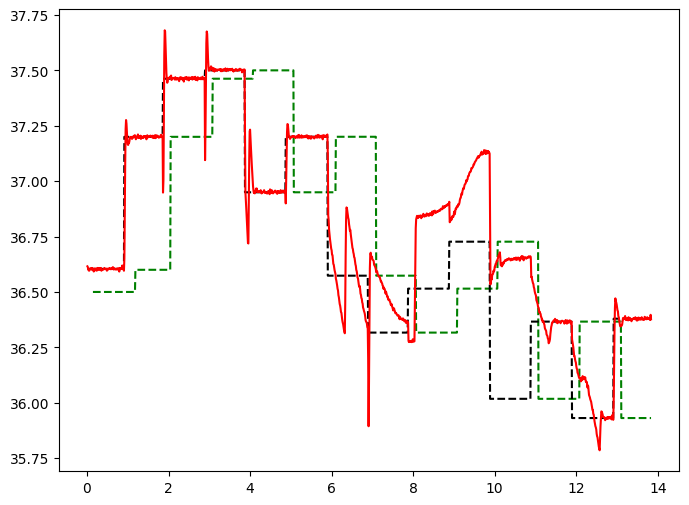

In [65]:
plt.figure(figsize=(8,6))
merged_data_temp2["Temp_setpoint"] = merged_data_temp2["Temp_setpoint"] #.shift(-112)
plt.plot(merged_data_temp2["Elapsed_time"], merged_data_temp2["Temp_setpoint"], "g--")
plt.plot(merged_data_temp2["Elapsed_time"], merged_data_temp2["FER027 TEMP PRI  CSP"], "k--")
plt.plot(merged_data_temp2["Elapsed_time"], merged_data_temp2["FER027 TEMP PRI  PV"], "r")

### Historical CTM Batches

In [13]:
all_ctm_data["Setpoint Tracking Error"] = np.nan
all_ctm_data["Specific Productivity (pg/cell/day)"] = np.nan
all_ctm_data["Specific Lactate Production (mmol/cell/day)"] = np.nan
all_ctm_data["IVC"] = np.nan
all_ctm_data["Cumulative IVC"] = np.nan
for group, data in all_ctm_data.groupby("Batch"):
    data["Setpoint Tracking Error"] = 100*(data["Titer"]-titer_setpoint_trajectory)/titer_range
    time_days = (data["Time"] - data["Time"].iloc[0]).dt.total_seconds() / 86400  # Convert time to hours
    titer = data["Titer"]*1000
    vcc = data["VCC"]
    qp, ivc = per_interval_qp_simple(time_days, titer, vcc)
    # Convert lactate from g/L -> mmol/L change per day
    dlac = data["lactate"].diff()           # g/L difference
    dt_days = data["Time"].diff().dt.total_seconds() / 86400  # time difference in days

    v_lac = (dlac / 0.09008) / dt_days      # mmol/L/day

    # Specific lactate rate
    vcc_avg = (data["VCC"] + data["VCC"].shift(1)) / 2         # cells/mL
    sp_lac = v_lac / vcc_avg      # mmol / (L * day) / (cells/mL) -> mmol/(10^9 cells)/day
    data["Specific Productivity (pg/cell/day)"] = np.insert(qp/1000, 0, np.nan)
    data["Specific Lactate Production (mmol/cell/day)"] = sp_lac
    data["IVC"] = np.insert(ivc, 0, 0)
    data["Cumulative IVC"] = np.cumsum(np.insert(ivc, 0, 0))

    all_ctm_data.loc[all_ctm_data["Batch"]==group, :] = data

all_ctm_data

,Batch,Time,Day,VCC,Viability,Titer,lactate,glucose,ammonium,glutamate,glutamine,osmolality,Total_Base_Added,Setpoint Tracking Error,Specific Productivity (pg/cell/day),Specific Lactate Production (mmol/cell/day),IVC,Cumulative IVC
0,CTM1,2025-03-05 10:50:00,0,0.61,100.0,23.9,0.06,6.38,0.49,2.80,0.70,309.0,0.0,0.087046,NaN,NaN,0.000,0.000
1,CTM1,2025-03-06 09:31:00,1,1.05,99.0,35.0,0.18,6.27,0.70,3.04,0.72,310.0,0.0,0.049271,14.149766,1.698162,0.830,0.830
2,CTM1,2025-03-07 14:20:00,2,2.33,99.0,66.8,0.40,5.72,1.15,3.28,0.64,301.0,0.0,0.195449,15.671404,1.203580,1.690,2.520
3,CTM1,2025-03-08 08:11:00,3,3.77,99.0,105.1,0.54,5.23,1.70,3.57,0.62,301.0,0.0,-0.543869,16.883868,0.685130,3.050,5.570
4,CTM1,2025-03-09 08:16:00,4,6.93,100.0,198.5,0.79,3.92,2.35,3.95,0.54,287.0,0.0,-1.172664,17.397536,0.516955,5.350,10.920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,CTM9,2025-09-05 09:11:00,10,17.28,93.4,2157.5,0.11,3.47,6.54,7.64,NaN,349.0,19.3,-6.182178,21.640502,-0.025707,16.990,94.105
131,CTM9,2025-09-06 08:56:00,11,16.33,89.6,2375.7,0.11,3.59,7.86,7.90,NaN,374.0,19.3,-7.444681,13.120907,0.000000,16.805,110.910
132,CTM9,2025-09-07 08:53:00,12,15.98,85.6,2610.2,0.13,3.44,8.03,7.80,NaN,373.0,19.3,-9.077762,14.545934,0.013772,16.155,127.065
133,CTM9,2025-09-08 08:48:00,13,15.19,84.3,2760.0,0.16,3.63,8.93,8.35,NaN,402.0,19.3,-10.432518,9.645297,0.021444,15.585,142.650


### Build DataFrame of MPC Batch Results

In [14]:
titer_results = pd.DataFrame({
    "Time": time_data,
    "Cedex Titer": cedex_titer,
    "Raman Titer": raman_titer,
    "HPLC Titer": hplc_titer,
    "Titer Setpoint": titer_setpoint_trajectory,
    "CTM Avg.": ctm_avg_trajectory
})
titer_results

,Time,Cedex Titer,Raman Titer,HPLC Titer,Titer Setpoint,CTM Avg.
0,2025-11-21 10:26:46.409000-05:00,81.55,-134.604270,22.4,21.050000,21.050000
1,2025-11-22 11:24:33.632000-05:00,81.55,-27.770000,38.1,33.386786,33.150000
2,2025-11-23 08:14:12.847000-05:00,88.91,-19.591527,69.6,60.400714,59.550000
3,2025-11-24 08:55:09.795000-05:00,153.62,-13.044402,136.0,122.907041,120.328571
4,2025-11-25 08:31:34.685000-05:00,294.48,145.848924,267.4,236.894694,230.314286
5,2025-11-26 08:34:55.952000-05:00,515.95,371.479461,472.0,423.577551,408.971429
6,2025-11-27 09:21:32.920000-05:00,852.00,671.221313,797.6,738.804694,708.442857
7,2025-11-28 09:04:34.734000-05:00,1218.22,970.264848,1163.3,1098.795000,1046.471429
8,2025-11-29 08:39:21.272000-05:00,1724.34,1426.332619,1551.0,1576.804082,1491.571429
9,2025-11-30 08:54:44.671000-05:00,2212.43,1943.398314,1983.9,1964.336939,1845.685714


### Titer Trend

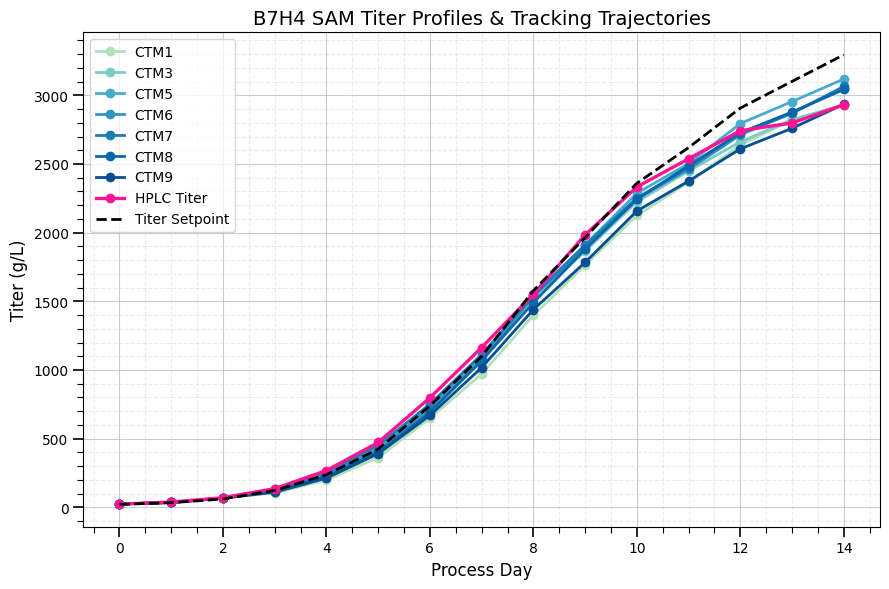

In [27]:
plt.figure(figsize=(9, 6))

x = np.arange(len(batch_data))

line_width = 2.4
marker_size = 6

# --- Main data series ---
# plt.plot(x, raman_titer,
#          color="green", linewidth=line_width,
#          marker="o", markersize=marker_size,
#          label="Raman Titer")

# plt.plot(x, ctm_avg_trajectory,
#          color="black", linewidth=line_width,
#          marker="o", markersize=marker_size,
#          label="CTM Avg. Titer")

# --- CTM batches with sequential blue colormap ---
groups = list(all_ctm_data["Batch"].unique())
norm = Normalize(vmin=0, vmax=len(groups)-1)  # normalize index to [0, 1]

for i, group in enumerate(groups):
    if group in ["CTM2", "CTM4"]:
        continue
    sub = all_ctm_data[all_ctm_data["Batch"] == group]
    y = sub["Titer"].values
    color = GnBu(0.35 + 0.6 * norm(i))  # light red to darker purple range

    plt.plot(
        x,
        y,
        marker="o",
        linestyle="-",
        linewidth=2.0,
        markersize=6,
        c=color,
        label=f"{group}",
    )

plt.plot(x, hplc_titer,
         color="deeppink", linewidth=line_width,
         marker="o", markersize=marker_size,
         label="HPLC Titer")

# --- Setpoint trajectory ---
plt.plot(x, titer_setpoint_trajectory,
         linestyle="--", color="black",
         linewidth=2, label="Titer Setpoint")

# --- Axes labels + title ---
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Titer (g/L)", fontsize=12)
plt.title("B7H4 SAM Titer Profiles & Tracking Trajectories", fontsize=14)

# --- Grid styling ---
plt.grid(which="major", linestyle="-", alpha=0.65)
plt.grid(which="minor", linestyle="--", alpha=0.25)
plt.minorticks_on()

# --- Tick appearance ---
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# --- Legend ---
plt.legend(frameon=True, fontsize=10, loc="best")
plt.savefig(save_path / 'figures/EOR/titer_profiles_w_ctms.png', format='png', dpi=300)
plt.tight_layout()


### Setpoint Tracking Graphs

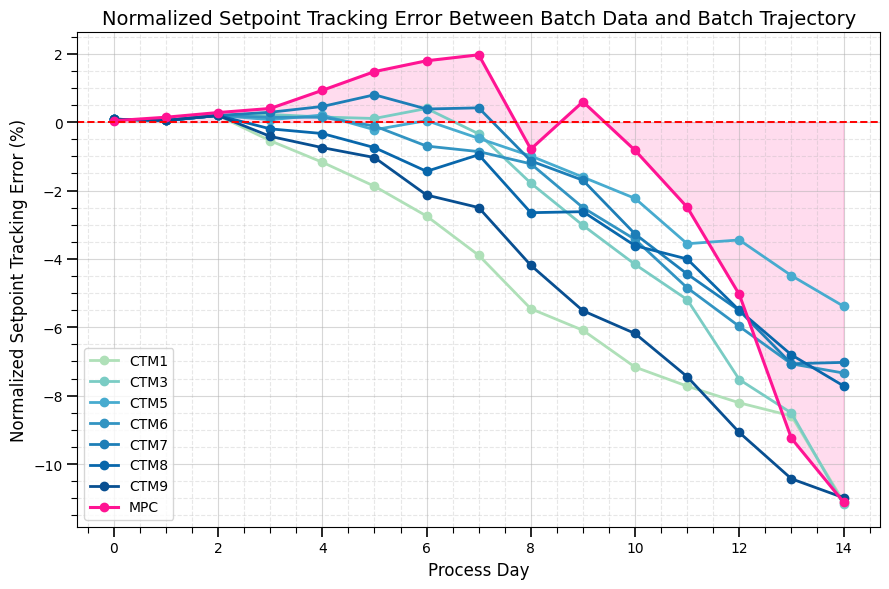

In [28]:
plt.figure(figsize=(9, 6))

start = 0

# Common x-axis
x = np.arange(start, len(batch_data))

# Plot styling parameters
line_width = 2.2
marker_size = 6
alpha_fill = 0.15

# --- CTM batches with sequential blue colormap ---
groups = list(all_ctm_data["Batch"].unique())
norm = Normalize(vmin=0, vmax=len(groups) - 1)  # normalize index to [0, 1]

for i, group in enumerate(groups):
    if group in ["CTM2", "CTM4"]:
        continue
    sub = all_ctm_data[all_ctm_data["Batch"] == group]
    y = sub["Setpoint Tracking Error"].values
    color = GnBu(0.35 + 0.6 * norm(i))  # light red to darker purple range

    plt.plot(
        x,
        y,
        marker="o",
        linestyle="-",
        linewidth=2.0,
        markersize=6,
        c=color,
        label=f"{group}",
    )

# --- MPC batch (deep pink) ---
plt.plot(
    x,
    setpoint_tracking_error_hplc[start:],
    color="deeppink",
    linewidth=line_width,
    marker="o",
    markersize=marker_size,
    label="MPC",
)

# Fill area underneath each line
plt.fill_between(
    x, setpoint_tracking_error_hplc[start:], alpha=alpha_fill, color="deeppink"
)

# Zero reference line
plt.axhline(0, linestyle="--", color="red", linewidth=1.4)

# Labels + title
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Normalized Setpoint Tracking Error (%)", fontsize=12)
plt.title(
    "Normalized Setpoint Tracking Error Between Batch Data and Batch Trajectory",
    fontsize=14,
)

# Grid (major + subtle minor)
plt.grid(which="major", linestyle="-", alpha=0.50)
plt.grid(which="minor", linestyle="--", alpha=0.30)

# Add minor ticks
plt.minorticks_on()

# Ticks appearance
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# Legend formatting
plt.legend(frameon=True, fontsize=10, loc="lower left")
plt.savefig(
    save_path / "figures/EOR/titer_setpoint_tracking_error.png", format="png", dpi=300
)
plt.tight_layout()

### __Specific Productivity__

In [17]:
# Extract cell count, titer, and time data
titer_mg_ml = hplc_titer * 1000
cell_count = np.array([values["total_viable_cells"] for _, values in mpc_data.items()])
lactate_ = np.array([values["LactateConcentration"] for _, values in mpc_data.items()])
time_days = (
    time_data - time_data.iloc[0]
).dt.total_seconds() / 86400  # Convert time to hours

# Calculate specific productivity
specific_productivity, integral_vcc = per_interval_qp_simple(
    time_days, titer_mg_ml, cell_count
)

# Convert lactate from g/L -> mmol/L change per day
dlac = pd.Series(lactate_).diff()  # g/L difference

v_lac = (dlac / 0.09008) / time_days  # mmol/L/day

# Specific lactate rate
vcc_avg = (pd.Series(cell_count) + pd.Series(cell_count).shift(1)) / 2  # cells/mL
sp_lac = v_lac / vcc_avg  # mmol / (L * day) / (cells/mL) -> mmol/(10^9 cells)/day

# Create a DataFrame for better visualization
specific_productivity_df = pd.DataFrame(
    {
        "Time (day)": time_days,
        "Titer (mg/mL)": titer_mg_ml,
        "Day Difference": np.diff(time_days, prepend=np.nan),
        "VCC (MM cells/mL)": cell_count,
        "Specific Productivity (pg/cell/day)": np.insert(
            specific_productivity / 1000, 0, np.nan
        ),
        "IVC": np.insert(integral_vcc, 0, 0),
        "Cumulative IVC": np.cumsum(np.insert(integral_vcc, 0, 0)),
        "Specific Lactate Production (mmol/cell/day)": sp_lac,
    }
)

specific_productivity_df

,Time (day),Titer (mg/mL),Day Difference,VCC (MM cells/mL),Specific Productivity (pg/cell/day),IVC,Cumulative IVC,Specific Lactate Production (mmol/cell/day)
0,0.000000,22400.0,NaN,0.59,NaN,0.000,0.000,NaN
1,1.040130,38100.0,1.040130,1.14,17.450021,0.865,0.865,1.604026
2,1.907945,69600.0,0.867815,2.65,19.154649,1.895,2.760,0.644786
3,2.936382,136000.0,1.028437,4.41,18.290085,3.530,6.290,0.406975
4,3.920003,267400.0,0.983621,7.71,22.044222,6.060,12.350,0.163561
5,4.922333,472000.0,1.002329,9.96,23.104074,8.835,21.185,-0.022974
6,5.954705,797600.0,1.032372,11.46,29.448188,10.710,31.895,-0.029592
7,6.942920,1163300.0,0.988215,12.91,30.370210,12.185,44.080,0.000000
8,7.925404,1551000.0,0.982483,13.32,30.088631,13.115,57.195,-0.046993
9,8.936091,1983900.0,1.010687,14.25,31.071622,13.785,70.980,-0.026135


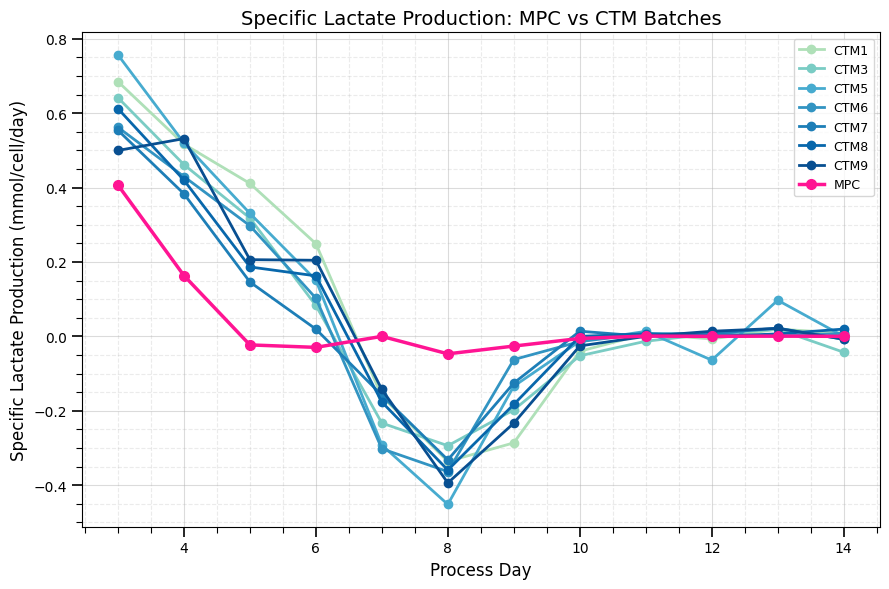

In [29]:
start_day = 3
x = np.arange(start_day, 15, 1)

plt.figure(figsize=(9, 6))

# --- CTM batches with sequential blue colormap ---
groups = list(all_ctm_data["Batch"].unique())
norm = Normalize(vmin=0, vmax=len(groups) - 1)  # normalize index to [0, 1]

for i, group in enumerate(groups):
    if group in ["CTM2", "CTM4"]:
        continue
    sub = all_ctm_data[all_ctm_data["Batch"] == group]
    y = sub["Specific Lactate Production (mmol/cell/day)"].values[start_day:]
    color = GnBu(0.35 + 0.6 * norm(i))  # light red to darker purple range

    plt.plot(
        x,
        y,
        marker="o",
        linestyle="-",
        linewidth=2.0,
        markersize=6,
        c=color,
        label=f"{group}",
    )

# --- MPC batch (deep pink) ---
y1 = specific_productivity_df["Specific Lactate Production (mmol/cell/day)"].values[
    start_day:
]
plt.plot(
    x,
    y1,
    marker="o",
    linestyle="-",
    linewidth=2.5,
    markersize=7,
    c="deeppink",
    label="MPC",
)

# --- Labels, title ---
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Specific Lactate Production (mmol/cell/day)", fontsize=12)
plt.title("Specific Lactate Production: MPC vs CTM Batches", fontsize=14)

# --- Grid ---
plt.grid(which="major", linestyle="-", alpha=0.45)
plt.grid(which="minor", linestyle="--", alpha=0.25)
plt.minorticks_on()

# --- Ticks ---
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# --- Limits + Legend ---
# plt.ylim(0, 35)
plt.legend(frameon=True, fontsize=9)
plt.savefig(
    save_path / "figures/EOR/specific_lactate_production.png", format="png", dpi=300
)
plt.tight_layout()
plt.show()


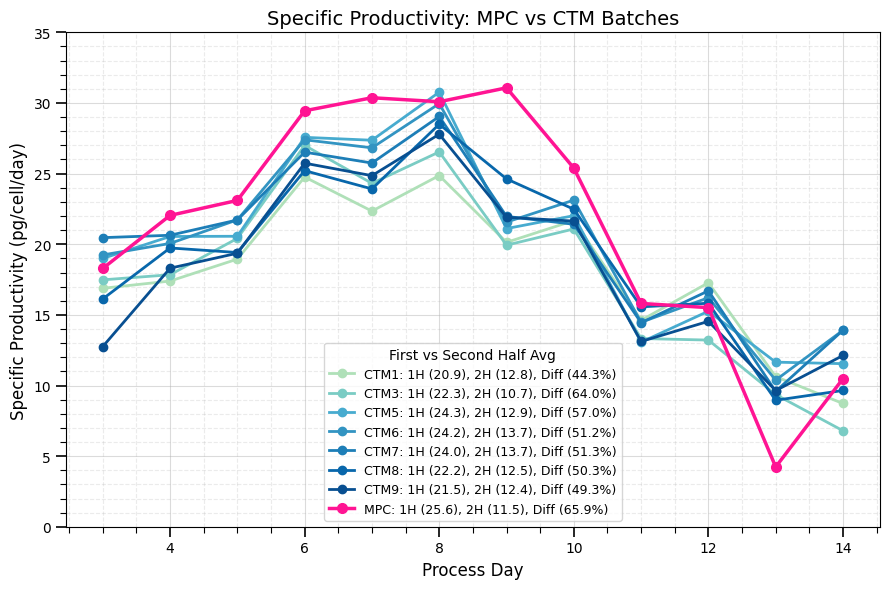

In [30]:
start_day = 3
x = np.arange(start_day, 15, 1)

plt.figure(figsize=(9, 6))

# --- CTM batches with sequential blue colormap ---
groups = list(all_ctm_data["Batch"].unique())
norm = Normalize(vmin=0, vmax=len(groups)-1)  # normalize index to [0, 1]

for i, group in enumerate(groups):
    if group in ["CTM2", "CTM4"]:
        continue
    sub = all_ctm_data[all_ctm_data["Batch"] == group]
    y = sub["Specific Productivity (pg/cell/day)"].values[start_day:]
    color = GnBu(0.35 + 0.6 * norm(i))  # light red to darker purple range

    plt.plot(
        x,
        y,
        marker="o",
        linestyle="-",
        linewidth=2.0,
        markersize=6,
        c=color,
        label=f"{group}: 1H ({np.mean(y[:6]):0.01f}), 2H ({np.mean(y[8:]):0.01f}), "
              f"Diff ({100*(np.mean(y[:6]) - np.mean(y[8:]))/np.mean(y):0.01f}%)",
    )

# --- MPC batch (deep pink) ---
y1 = specific_productivity_df["Specific Productivity (pg/cell/day)"].values[start_day:]
plt.plot(
    x,
    y1,
    marker="o",
    linestyle="-",
    linewidth=2.5,
    markersize=7,
    c="deeppink",
    label=f"MPC: 1H ({np.mean(y1[:6]):0.01f}), 2H ({np.mean(y1[8:]):0.01f}), "
          f"Diff ({100*(np.mean(y1[:6]) - np.mean(y1[8:]))/np.mean(y1):0.01f}%)",
)

# --- Labels, title ---
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Specific Productivity (pg/cell/day)", fontsize=12)
plt.title("Specific Productivity: MPC vs CTM Batches", fontsize=14)

# --- Grid ---
plt.grid(which="major", linestyle="-", alpha=0.45)
plt.grid(which="minor", linestyle="--", alpha=0.25)
plt.minorticks_on()

# --- Ticks ---
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# --- Limits + Legend ---
plt.ylim(0, 35)
plt.legend(frameon=True, fontsize=9, title="First vs Second Half Avg")
plt.savefig(save_path / 'figures/EOR/specific_productivity.png', format='png', dpi=300)
plt.tight_layout()
plt.show()

### __Integral of Viable Cell Concentration__

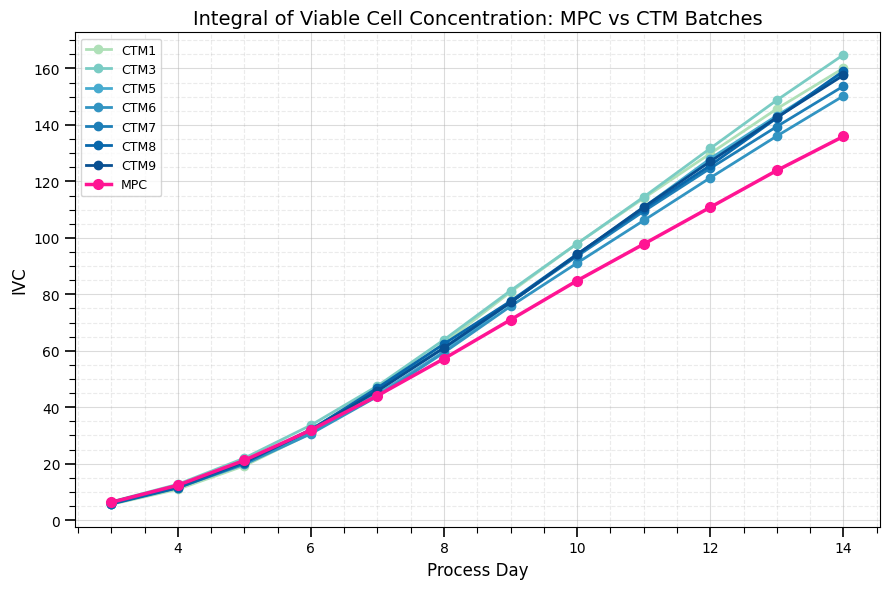

In [31]:
start_day = 3
x = np.arange(start_day, 15, 1)

plt.figure(figsize=(9, 6))

# --- CTM batches with sequential blue colormap ---
groups = list(all_ctm_data["Batch"].unique())
norm = Normalize(vmin=0, vmax=len(groups)-1)  # normalize index to [0, 1]

for i, group in enumerate(groups):
    if group in ["CTM2", "CTM4"]:
        continue
    sub = all_ctm_data[all_ctm_data["Batch"] == group]
    y = sub["Cumulative IVC"].values[start_day:]
    color = GnBu(0.35 + 0.6 * norm(i))  # light red to darker purple range

    plt.plot(
        x,
        y,
        marker="o",
        linestyle="-",
        linewidth=2.0,
        markersize=6,
        c=color,
        label=f"{group}",
    )

# --- MPC batch (deep pink) ---
y1 = specific_productivity_df["Cumulative IVC"].values[start_day:]
plt.plot(
    x,
    y1,
    marker="o",
    linestyle="-",
    linewidth=2.5,
    markersize=7,
    c="deeppink",
    label="MPC",
)

# --- Labels, title ---
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("IVC", fontsize=12)
plt.title("Integral of Viable Cell Concentration: MPC vs CTM Batches", fontsize=14)

# --- Grid ---
plt.grid(which="major", linestyle="-", alpha=0.45)
plt.grid(which="minor", linestyle="--", alpha=0.25)
plt.minorticks_on()

# --- Ticks ---
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# --- Limits + Legend ---
# plt.ylim(0, 35)
plt.legend(frameon=True, fontsize=9)
plt.savefig(save_path / 'figures/EOR/integral_viable_cells.png', format='png', dpi=300)
plt.tight_layout()
plt.show()

### __Degree-hours (Thermal Exposure)__

### __Viability__

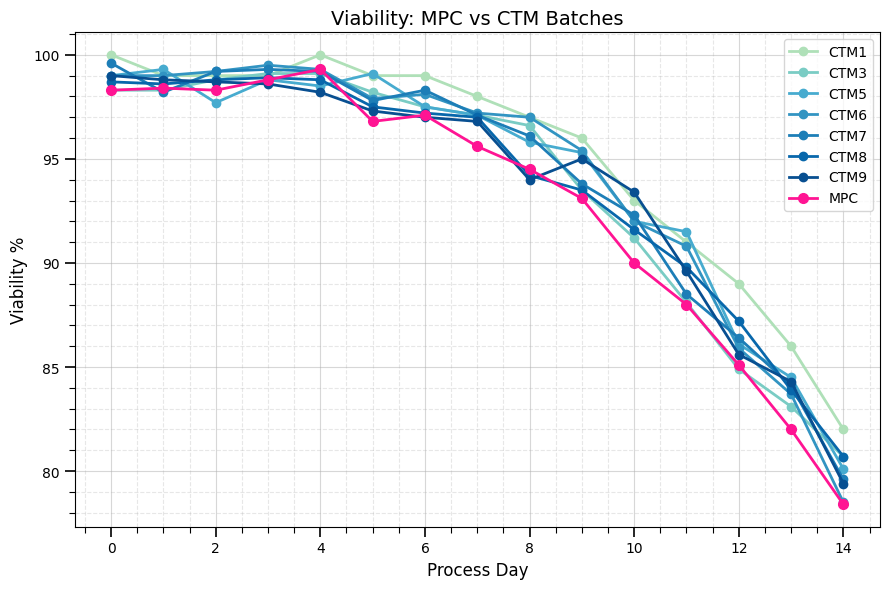

In [32]:
x = np.arange(0, 15, 1)
viability = np.array([values["CellCultureViability"] for _, values in mpc_data.items()])
# viability_ctm1 = np.array([values["CellCultureViability"] for _, values in data_ctm1.items()])
# viability_ctm2 = np.array([values["CellCultureViability"] for _, values in data_ctm2.items()])

plt.figure(figsize=(9, 6))

# --- CTM batches with sequential blue colormap ---
groups = list(all_ctm_data["Batch"].unique())
norm = Normalize(vmin=0, vmax=len(groups)-1)  # normalize index to [0, 1]

for i, group in enumerate(groups):
    if group in ["CTM2", "CTM4"]:
        continue
    sub = all_ctm_data[all_ctm_data["Batch"] == group]
    y = sub["Viability"].values
    color = GnBu(0.35 + 0.6 * norm(i))  # light red to darker purple range

    plt.plot(
        x,
        y,
        marker="o",
        linestyle="-",
        linewidth=2.0,
        markersize=6,
        c=color,
        label=f"{group}",
    )

plt.plot(
    x,
    viability,
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=7,
    c="deeppink",
    label="MPC",
)

# Labels and title
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Viability %", fontsize=12)
plt.title("Viability: MPC vs CTM Batches", fontsize=14)

# Grid (major + subtle minor)
plt.grid(which="major", linestyle="-", alpha=0.50)
plt.grid(which="minor", linestyle="--", alpha=0.30)

# Add minor ticks
plt.minorticks_on()

# Ticks appearance
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)
plt.legend(frameon=True)
plt.savefig(save_path / 'figures/EOR/viability.png', format='png', dpi=300)
# Clean layout for slides
plt.tight_layout()
plt.show()